<a href="https://colab.research.google.com/github/jellybbie/study/blob/project2/Colab_%EC%8B%9C%EC%9E%91%ED%95%98%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 건조 실험

In [1]:
import pandas as pd

### Load the data

I'll load the `/content/drought stress-v3.xlsx` file into a pandas DataFrame and display the first 5 rows to ensure it's loaded correctly.

In [2]:
file_path = '/content/drought stress-v3.xlsx'
df = pd.read_excel(file_path)
display(df.head())

,Type,Strain,repeat1,repeat2,repeat3
0,Bacteria,1R-RH9-M1-A6,1.0,1.0,1.0
1,Bacteria,1R-RH9-M1-B2,1.0,1.0,0.0
2,Bacteria,1R-RH9-M1-B3,1.0,1.0,0.0
3,Bacteria,2R-RH6-M1-F5,1.0,0.5,1.0
4,Bacteria,2R-RH6-M1-F6,0.5,1.0,0.5


### Data Processing for Visualization

First, I'll calculate the average drought resistance score from the `repeat1`, `repeat2`, and `repeat3` columns for each strain. This will give us a single metric to compare strains.


In [3]:
df['average_resistance'] = df[['repeat1', 'repeat2', 'repeat3']].mean(axis=1)

# Display the DataFrame with the new average resistance column
display(df.head())

,Type,Strain,repeat1,repeat2,repeat3,average_resistance
0,Bacteria,1R-RH9-M1-A6,1.0,1.0,1.0,1.000000
1,Bacteria,1R-RH9-M1-B2,1.0,1.0,0.0,0.666667
2,Bacteria,1R-RH9-M1-B3,1.0,1.0,0.0,0.666667
3,Bacteria,2R-RH6-M1-F5,1.0,0.5,1.0,0.833333
4,Bacteria,2R-RH6-M1-F6,0.5,1.0,0.5,0.666667


### Visualization of Drought Resistance

Now, I'll create a bar plot to visualize the average drought resistance score for each strain. The strains will be grouped and colored by their 'Type' (Bacteria, Yeast, Lactic Acid Bacteria, Bacillus, etc.), allowing for easy comparison across different organism types.


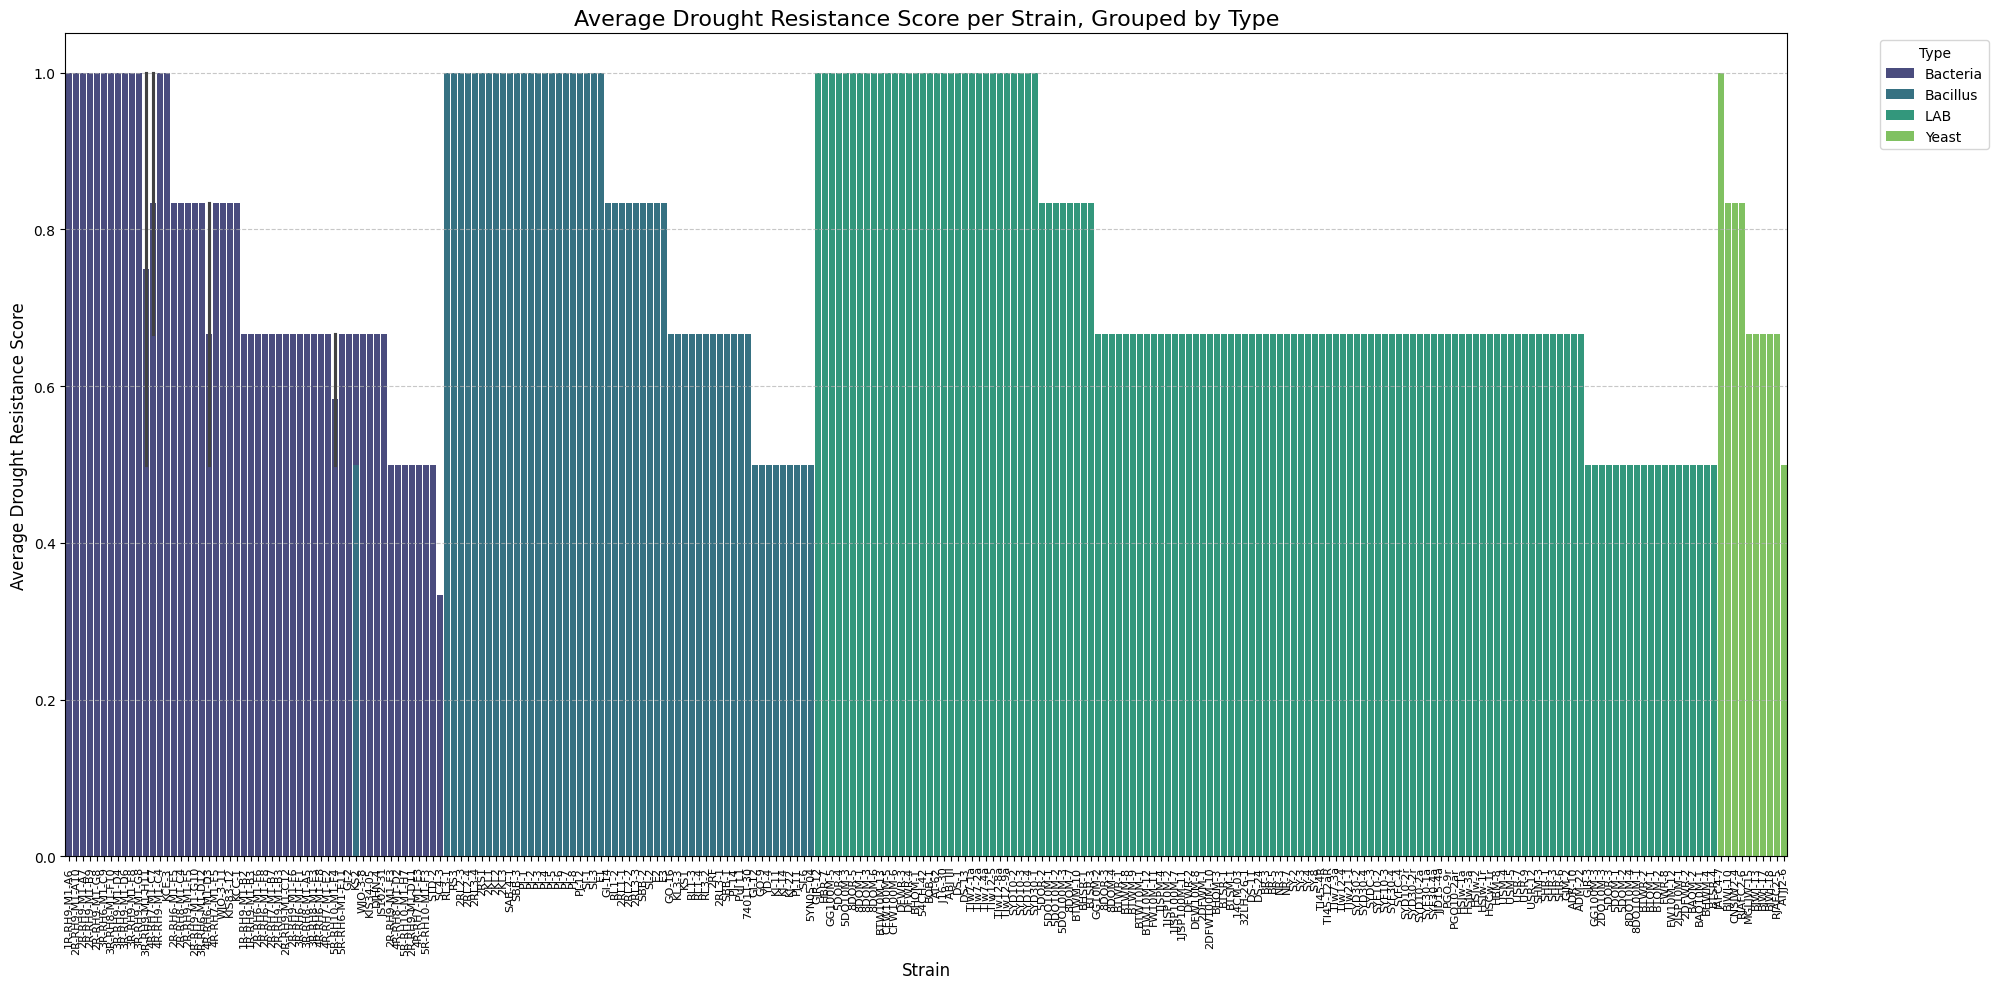

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the desired order for 'Type'
desired_order = ['Bacteria', 'Bacillus', 'LAB', 'Yeast']

# Convert 'Type' to a categorical type with the desired order
df['Type'] = pd.Categorical(df['Type'], categories=desired_order, ordered=True)

# Sort by Type and then by average resistance for better visualization
df_sorted = df.sort_values(by=['Type', 'average_resistance'], ascending=[True, False])

plt.figure(figsize=(20, 10)) # Increased figure size for better readability of many strains
sns.barplot(x='Strain', y='average_resistance', hue='Type', data=df_sorted, palette='viridis', dodge=False)

plt.title('Average Drought Resistance Score per Strain, Grouped by Type', fontsize=16)
plt.xlabel('Strain', fontsize=12)
plt.ylabel('Average Drought Resistance Score', fontsize=12)
plt.xticks(rotation=90, fontsize=8) # Rotate x-axis labels for better readability
plt.yticks(fontsize=10)
plt.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside the plot
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for readability
plt.show()

### Boxplot of Average Drought Resistance by Type

This boxplot will illustrate the distribution of average drought resistance scores for each organism 'Type'. It provides insights into the median, quartiles, and any potential outliers within each category, while maintaining the specified order of types.

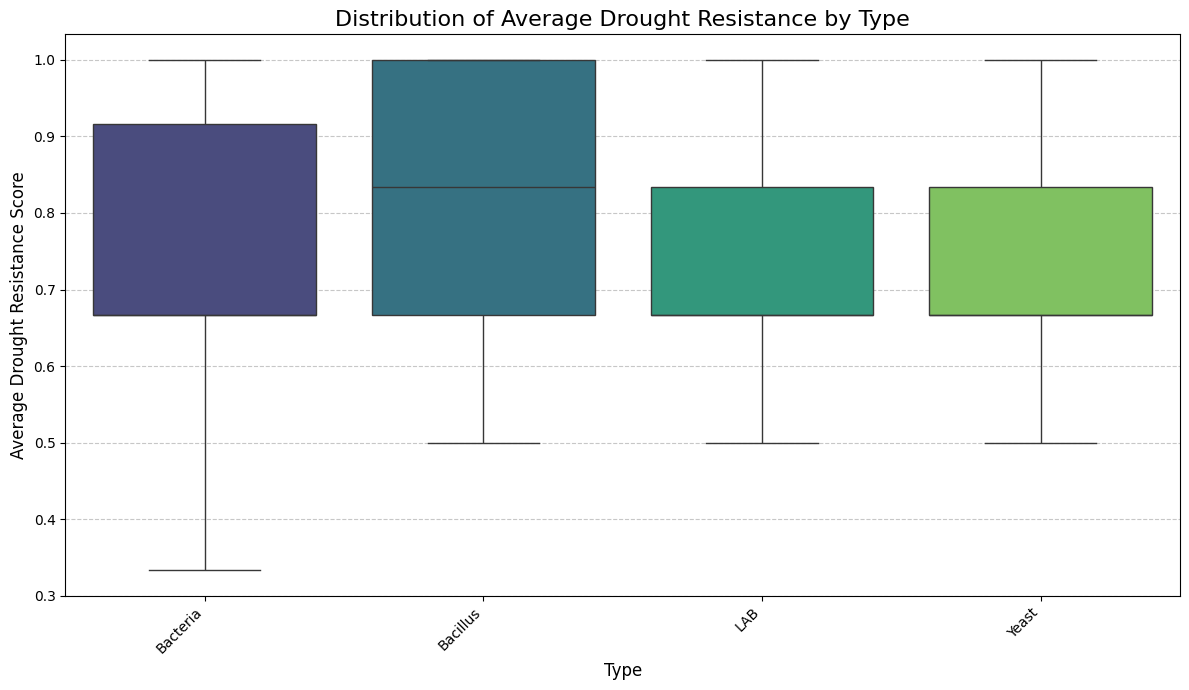

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Type' is categorical with the desired order for plotting
desired_order = ['Bacteria', 'Bacillus', 'LAB', 'Yeast']
df['Type'] = pd.Categorical(df['Type'], categories=desired_order, ordered=True)

plt.figure(figsize=(12, 7))
sns.boxplot(x='Type', y='average_resistance', hue='Type', data=df, palette='viridis', legend=False)
# sns.stripplot(x='Type', y='average_resistance', data=df, color='black', size=4, alpha=0.7, jitter=0.2) # Removed stripplot

plt.title('Distribution of Average Drought Resistance by Type', fontsize=16)
plt.xlabel('Type', fontsize=12)
plt.ylabel('Average Drought Resistance Score', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Visualization of Drought Resistance (Original Strain Order)

This new plot will display the average drought resistance for each strain, maintaining their original order as they appear in the dataset. The strains will still be colored and grouped by their 'Type' (Bacteria, Bacillus, LAB, Yeast) for consistent comparison.

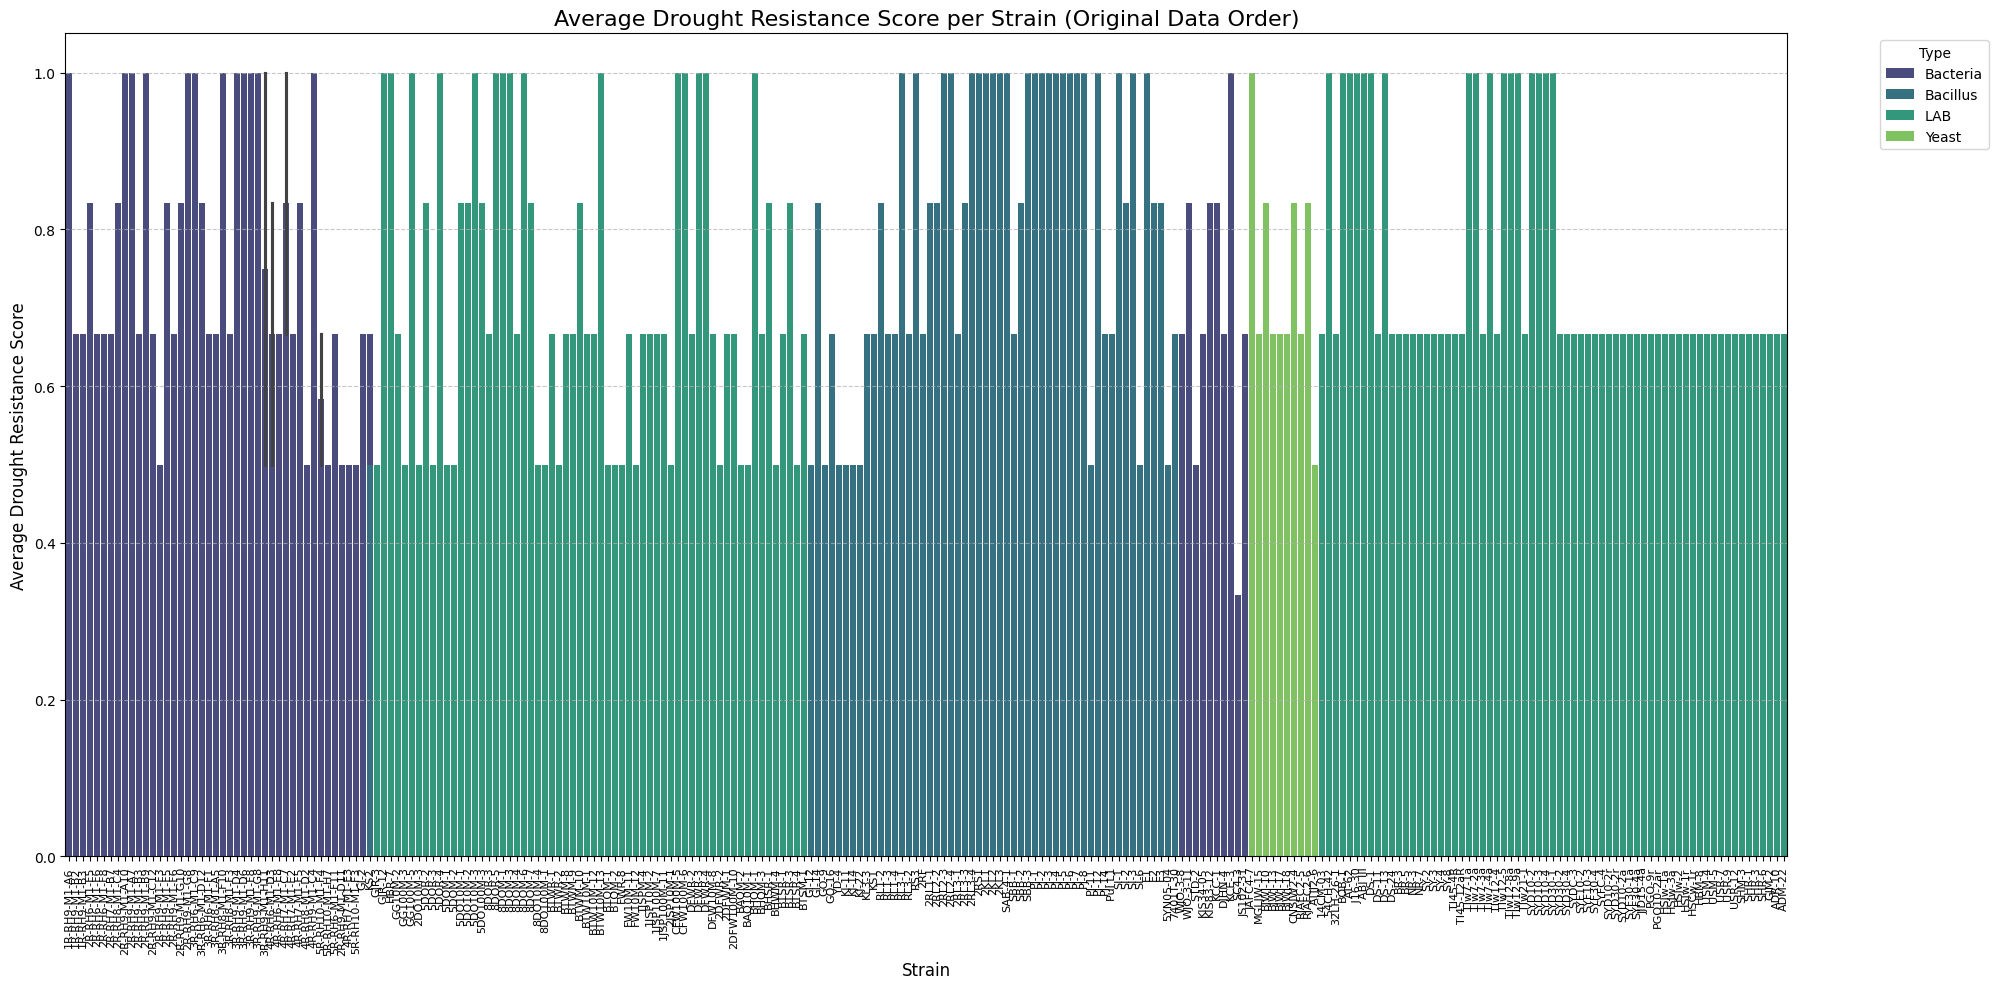

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the desired order for 'Type' (already set in df, but good for clarity)
desired_order = ['Bacteria', 'Bacillus', 'LAB', 'Yeast']

# Ensure 'Type' is categorical with the desired order (in case df was reset or for a new session)
# df['Type'] = pd.Categorical(df['Type'], categories=desired_order, ordered=True)
# Note: The 'Type' column in 'df' should already be categorical with the correct order from the previous plot.

plt.figure(figsize=(20, 10)) # Increased figure size for better readability
sns.barplot(x='Strain', y='average_resistance', hue='Type', data=df, palette='viridis', dodge=False)

plt.title('Average Drought Resistance Score per Strain (Original Data Order)', fontsize=16)
plt.xlabel('Strain', fontsize=12)
plt.ylabel('Average Drought Resistance Score', fontsize=12)
plt.xticks(rotation=90, fontsize=8) # Rotate x-axis labels for better readability
plt.yticks(fontsize=10)
plt.legend(title='Type', bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside the plot
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for readability
plt.show()

### Summary Statistics by Type

I will now calculate the summary statistics (mean, standard deviation, min, max, etc.) for the `average_resistance` score, grouped by the `Type` of organism. This will help us understand the distribution of drought resistance within each category.

In [5]:
summary_stats = df.groupby('Type')['average_resistance'].describe()
display(summary_stats)

,count,mean,std,min,25%,50%,75%,max
Type,,,,,,,,
Bacillus,54.0,0.805556,0.196270,0.500000,0.666667,0.833333,1.000000,1.0
Bacteria,59.0,0.745763,0.184027,0.333333,0.666667,0.666667,0.916667,1.0
LAB,129.0,0.735142,0.170034,0.500000,0.666667,0.666667,0.833333,1.0
Yeast,10.0,0.733333,0.140546,0.500000,0.666667,0.666667,0.833333,1.0


### Reordering Summary Statistics Table

I will now reorder the summary statistics table to follow the sequence: Bacteria, Bacillus, LAB, and Yeast, for better comparison as requested.

In [6]:
desired_order = ['Bacteria', 'Bacillus', 'LAB', 'Yeast']
summary_stats_ordered = summary_stats.reindex(desired_order)
display(summary_stats_ordered)

,count,mean,std,min,25%,50%,75%,max
Type,,,,,,,,
Bacteria,59.0,0.745763,0.184027,0.333333,0.666667,0.666667,0.916667,1.0
Bacillus,54.0,0.805556,0.196270,0.500000,0.666667,0.833333,1.000000,1.0
LAB,129.0,0.735142,0.170034,0.500000,0.666667,0.666667,0.833333,1.0
Yeast,10.0,0.733333,0.140546,0.500000,0.666667,0.666667,0.833333,1.0


## Analysis of New Data: `drought stress-total-select.xlsx`

I will now load and analyze the new Excel file, `/content/drought stress-total-select.xlsx`, to identify and visualize strains with drought resistance activity.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path_new = '/content/drought stress-total-select.xlsx'
df_all_strains = pd.read_excel(file_path_new, header=0) # Load with header=0 to correctly interpret the first row as column names

print("First 5 rows of the new DataFrame:")
display(df_all_strains.head())
print("\nColumn Information:")
df_all_strains.info()
print("\nColumn names (indices):")
print(df_all_strains.columns)

First 5 rows of the new DataFrame:


,Type,Strain,Type.1,Strain.1,repeat1,repeat2,repeat3
0,Bacteria,5R-RH10-M1-A1,Bacteria,1R-RH9-M1-A6,1.0,1.0,1.0
1,Bacteria,5R-RH10-M1-B1,Bacteria,1R-RH9-M1-B2,1.0,1.0,0.0
2,Bacteria,5R-RH10-M1-C1,Bacteria,1R-RH9-M1-B3,1.0,1.0,0.0
3,Bacteria,5R-RH10-M1-D1,Bacteria,2R-RH6-M1-F5,1.0,0.5,1.0
4,Bacteria,5R-RH10-M1-E1,Bacteria,2R-RH6-M1-F6,0.5,1.0,0.5



Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7778 entries, 0 to 7777
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Type      7778 non-null   object 
 1   Strain    7778 non-null   object 
 2   Type.1    252 non-null    object 
 3   Strain.1  252 non-null    object 
 4   repeat1   252 non-null    float64
 5   repeat2   252 non-null    float64
 6   repeat3   252 non-null    float64
dtypes: float64(3), object(4)
memory usage: 425.5+ KB

Column names (indices):
Index(['Type', 'Strain', 'Type.1', 'Strain.1', 'repeat1', 'repeat2',
       'repeat3'],
      dtype='object')


Based on your description and the initial inspection, I will rename the columns for clarity and process the resistance scores.

*   Column 0: `Type` (Type of strain for all strains)
*   Column 1: `Strain` (All strains used in the experiment)
*   Column 2: `Type_Active` (Type for active strains, might be redundant with `Type`)
*   Column 3: `Strain_Active` (Strains that have drought resistance values above the threshold)
*   Column 4: `repeat1`
*   Column 5: `repeat2`
*   Column 6: `repeat3`

I will calculate the `total_resistance_score` by summing the three repeats, treating any missing values (`NaN`) in the repeat columns as 0. A strain is considered to have 'drought resistance activity' if its `total_resistance_score` is greater than 1.5, as per your description.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path_new = '/content/drought stress-total-select.xlsx'
df_all_strains = pd.read_excel(file_path_new, header=0) # Load with header=0 to correctly interpret the first row as column names

print("First 5 rows of the new DataFrame:")
display(df_all_strains.head())
print("\nColumn Information:")
df_all_strains.info()
print("\nColumn names (indices):")
print(df_all_strains.columns)

First 5 rows of the new DataFrame:


,Type,Strain,Type.1,Strain.1,repeat1,repeat2,repeat3
0,Bacteria,5R-RH10-M1-A1,Bacteria,1R-RH9-M1-A6,1.0,1.0,1.0
1,Bacteria,5R-RH10-M1-B1,Bacteria,1R-RH9-M1-B2,1.0,1.0,0.0
2,Bacteria,5R-RH10-M1-C1,Bacteria,1R-RH9-M1-B3,1.0,1.0,0.0
3,Bacteria,5R-RH10-M1-D1,Bacteria,2R-RH6-M1-F5,1.0,0.5,1.0
4,Bacteria,5R-RH10-M1-E1,Bacteria,2R-RH6-M1-F6,0.5,1.0,0.5



Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7778 entries, 0 to 7777
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Type      7778 non-null   object 
 1   Strain    7778 non-null   object 
 2   Type.1    252 non-null    object 
 3   Strain.1  252 non-null    object 
 4   repeat1   252 non-null    float64
 5   repeat2   252 non-null    float64
 6   repeat3   252 non-null    float64
dtypes: float64(3), object(4)
memory usage: 425.5+ KB

Column names (indices):
Index(['Type', 'Strain', 'Type.1', 'Strain.1', 'repeat1', 'repeat2',
       'repeat3'],
      dtype='object')


In [21]:
# Rename columns from Type.1 and Strain.1 to Type_Active and Strain_Active for clarity
df_all_strains = df_all_strains.rename(columns={'Type.1': 'Type_Active', 'Strain.1': 'Strain_Active'})

# Convert repeat columns to numeric, coercing errors to NaN
# This ensures that these columns are treated as numbers and handles any non-numeric entries (e.g., from header rows if not loaded correctly)
df_all_strains['repeat1'] = pd.to_numeric(df_all_strains['repeat1'], errors='coerce')
df_all_strains['repeat2'] = pd.to_numeric(df_all_strains['repeat2'], errors='coerce')
df_all_strains['repeat3'] = pd.to_numeric(df_all_strains['repeat3'], errors='coerce')

# Fill NaN values in repeat columns with 0 before summing, as per problem description for inactive strains
df_all_strains['total_resistance_score'] = df_all_strains[['repeat1', 'repeat2', 'repeat3']].fillna(0).sum(axis=1)

# Identify strains with drought resistance activity
# Active strains are those with total_resistance_score > 1.5
df_all_strains['has_drought_resistance_activity'] = df_all_strains['total_resistance_score'] > 1.5

# Display the DataFrame with new columns
print("DataFrame with total_resistance_score and activity flag:")
display(df_all_strains.head())

print("\nSummary of drought resistance activity:")
display(df_all_strains['has_drought_resistance_activity'].value_counts())

DataFrame with total_resistance_score and activity flag:


,Type,Strain,Type_Active,Strain_Active,repeat1,repeat2,repeat3,total_resistance_score,has_drought_resistance_activity
0,Bacteria,5R-RH10-M1-A1,Bacteria,1R-RH9-M1-A6,1.0,1.0,1.0,3.0,True
1,Bacteria,5R-RH10-M1-B1,Bacteria,1R-RH9-M1-B2,1.0,1.0,0.0,2.0,True
2,Bacteria,5R-RH10-M1-C1,Bacteria,1R-RH9-M1-B3,1.0,1.0,0.0,2.0,True
3,Bacteria,5R-RH10-M1-D1,Bacteria,2R-RH6-M1-F5,1.0,0.5,1.0,2.5,True
4,Bacteria,5R-RH10-M1-E1,Bacteria,2R-RH6-M1-F6,0.5,1.0,0.5,2.0,True



Summary of drought resistance activity:


,count
has_drought_resistance_activity,
False,7567
True,211


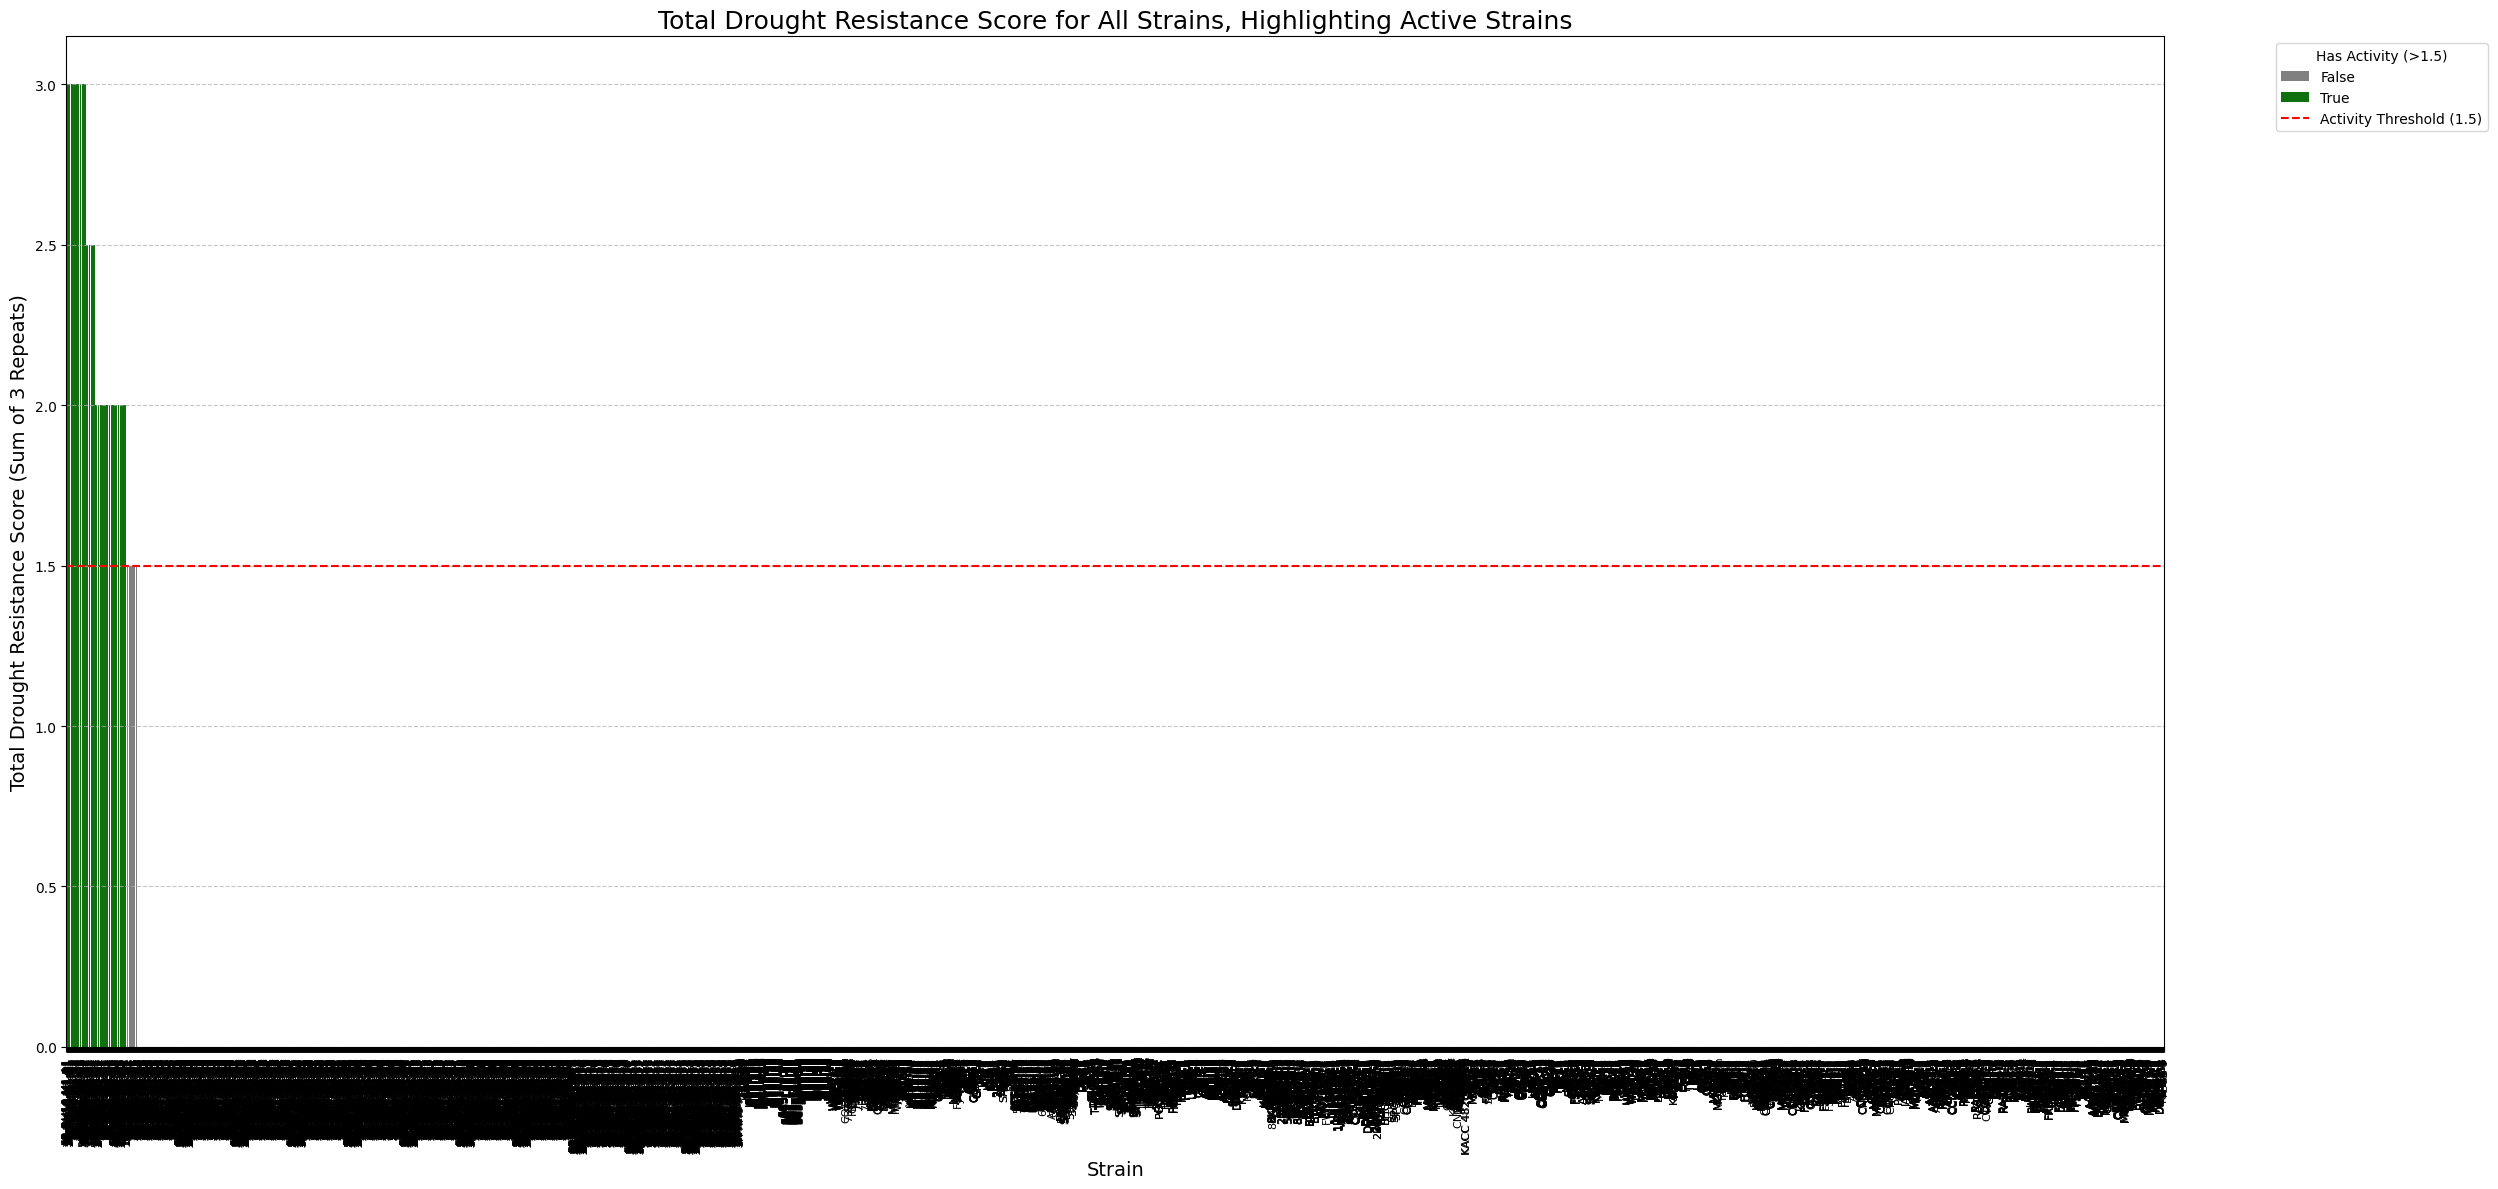

In [22]:
# Define the desired order for 'Type' for consistent visualization if needed, or let Seaborn handle it
desired_order_types = ['Bacteria', 'Bacillus', 'LAB', 'Yeast']

# Convert 'Type' to a categorical type with the desired order (from the main Type column)
df_all_strains['Type'] = pd.Categorical(df_all_strains['Type'], categories=desired_order_types, ordered=True)

# Sort for better visualization: first by Type, then by activity (active first), then by score
df_plot = df_all_strains.sort_values(by=['Type', 'has_drought_resistance_activity', 'total_resistance_score'], ascending=[True, False, False])

plt.figure(figsize=(25, 12)) # Increase figure size for many strains

sns.barplot(
    x='Strain',
    y='total_resistance_score',
    hue='has_drought_resistance_activity', # Color by activity
    data=df_plot,
    palette={True: 'green', False: 'gray'}, # Green for active, gray for inactive
    dodge=False # Avoid dodging bars if we want them aligned
)

plt.axhline(y=1.5, color='red', linestyle='--', label='Activity Threshold (1.5)') # Add a threshold line

plt.title('Total Drought Resistance Score for All Strains, Highlighting Active Strains', fontsize=18)
plt.xlabel('Strain', fontsize=14)
plt.ylabel('Total Drought Resistance Score (Sum of 3 Repeats)', fontsize=14)
plt.xticks(rotation=90, fontsize=8) # Rotate x-axis labels
plt.yticks(fontsize=10)
plt.legend(title='Has Activity (>1.5)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Adjust layout
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Visualization: Proportion of Active Strains by Type (Pie Charts)

Now, let's visualize the ratio of active drought-resistant strains to the total number of strains for each 'Type' using pie charts. This will provide a clear, proportional view of which types have a higher prevalence of active strains.

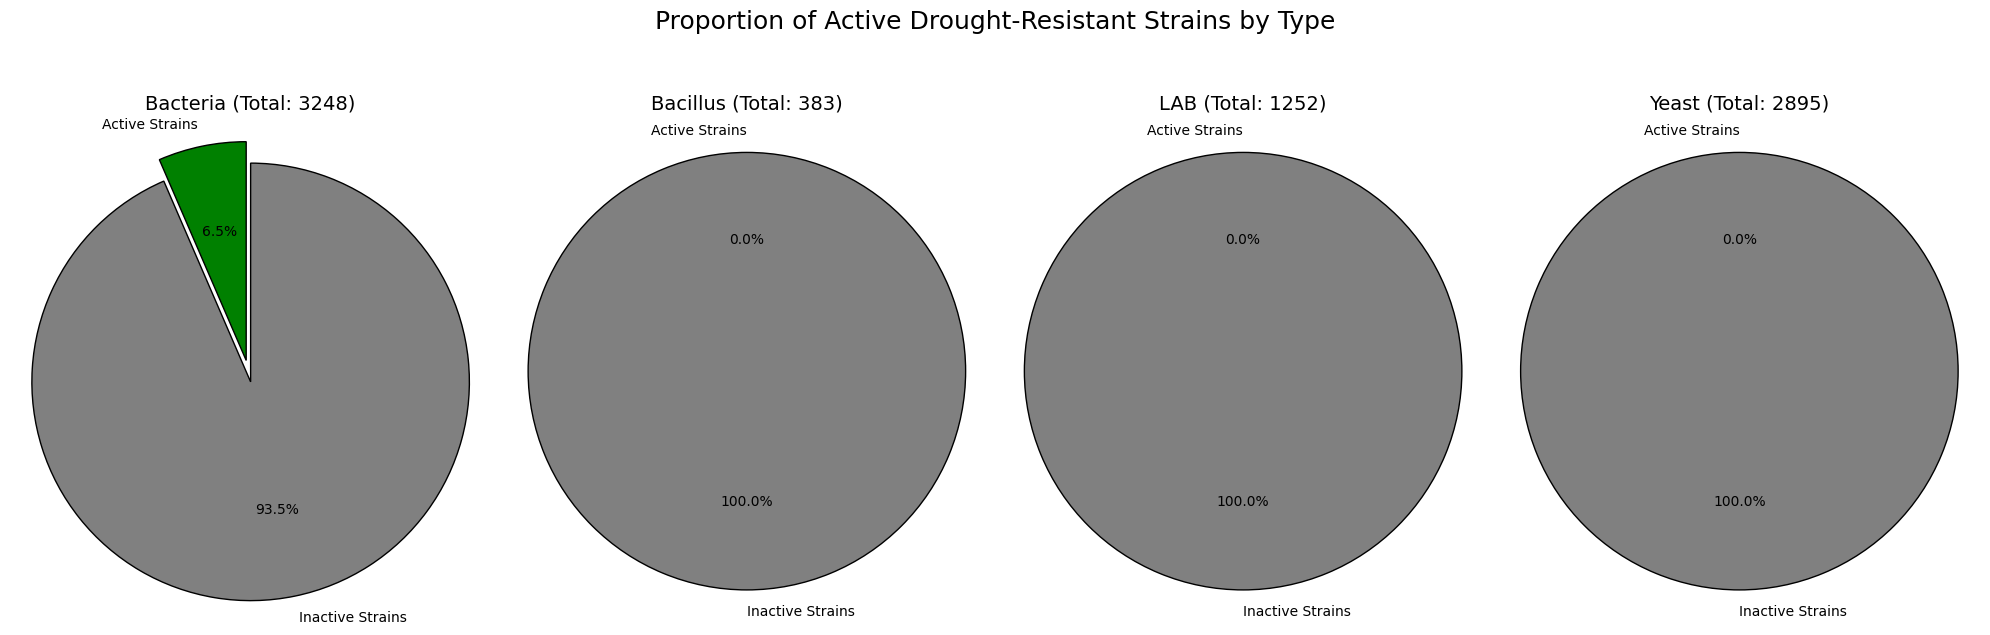

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Type' is categorical with the desired order, for consistent visualization
desired_order_types = ['Bacteria', 'Bacillus', 'LAB', 'Yeast']
df_all_strains['Type'] = pd.Categorical(df_all_strains['Type'], categories=desired_order_types, ordered=True)

# Calculate counts of active and inactive strains per Type
# Explicitly set observed=False to retain current behavior with categorical data and silence FutureWarning
total_strains_by_type = df_all_strains.groupby('Type', observed=False).size().rename('total_strains')
active_strains_by_type = df_all_strains[df_all_strains['has_drought_resistance_activity']].groupby('Type', observed=False).size().rename('active_strains')

# Combine these into a single DataFrame
type_summary = pd.DataFrame({
    'total_strains': total_strains_by_type,
    'active_strains': active_strains_by_type
}).fillna(0).astype(int) # Fill NaN with 0 for types with no active strains

type_summary['inactive_strains'] = type_summary['total_strains'] - type_summary['active_strains']

# Plot pie charts for each Type
# Determine the number of subplots dynamically
num_types = len(type_summary)
fig, axes = plt.subplots(1, num_types, figsize=(5 * num_types, 6))

# Adjust axes to be an iterable even if there's only one subplot
if num_types == 1:
    axes = [axes]

for i, (type_name, row) in enumerate(type_summary.iterrows()):
    # Only plot if there are any strains for this type
    if row['total_strains'] > 0:
        labels = ['Active Strains', 'Inactive Strains']
        sizes = [row['active_strains'], row['inactive_strains']]
        colors = ['green', 'gray'] # Consistent with previous visualization
        explode = [0.1 if sizes[0] > 0 else 0, 0] # Explode 'Active Strains' slice if present

        axes[i].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'}, explode=explode)
        axes[i].set_title(f'{type_name} (Total: {row["total_strains"]})', fontsize=14)
        axes[i].axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
    else:
        axes[i].set_title(f'{type_name} (No Strains)', fontsize=14)
        axes[i].text(0.5, 0.5, 'No data', horizontalalignment='center', verticalalignment='center', transform=axes[i].transAxes, fontsize=12)

plt.suptitle('Proportion of Active Drought-Resistant Strains by Type', fontsize=18, y=1.05)
plt.tight_layout(rect=[0, 0, 1, 1]) # Adjust layout to prevent overlap, leaving space for suptitle
plt.show()

In [19]:
# Rename columns from Type.1 and Strain.1 to Type_Active and Strain_Active for clarity
df_all_strains = df_all_strains.rename(columns={'Type.1': 'Type_Active', 'Strain.1': 'Strain_Active'})

# Convert repeat columns to numeric, coercing errors to NaN
# This ensures that these columns are treated as numbers and handles any non-numeric entries (e.g., from header rows if not loaded correctly)
df_all_strains['repeat1'] = pd.to_numeric(df_all_strains['repeat1'], errors='coerce')
df_all_strains['repeat2'] = pd.to_numeric(df_all_strains['repeat2'], errors='coerce')
df_all_strains['repeat3'] = pd.to_numeric(df_all_strains['repeat3'], errors='coerce')

# Fill NaN values in repeat columns with 0 before summing, as per problem description for inactive strains
df_all_strains['total_resistance_score'] = df_all_strains[['repeat1', 'repeat2', 'repeat3']].fillna(0).sum(axis=1)

# Identify strains with drought resistance activity
# Active strains are those with total_resistance_score > 1.5
df_all_strains['has_drought_resistance_activity'] = df_all_strains['total_resistance_score'] > 1.5

# Display the DataFrame with new columns
print("DataFrame with total_resistance_score and activity flag:")
display(df_all_strains.head())

print("\nSummary of drought resistance activity:")
display(df_all_strains['has_drought_resistance_activity'].value_counts())

DataFrame with total_resistance_score and activity flag:


,Type,Strain,Type_Active,Strain_Active,repeat1,repeat2,repeat3,total_resistance_score,has_drought_resistance_activity
0,Bacteria,5R-RH10-M1-A1,Bacteria,1R-RH9-M1-A6,1.0,1.0,1.0,3.0,True
1,Bacteria,5R-RH10-M1-B1,Bacteria,1R-RH9-M1-B2,1.0,1.0,0.0,2.0,True
2,Bacteria,5R-RH10-M1-C1,Bacteria,1R-RH9-M1-B3,1.0,1.0,0.0,2.0,True
3,Bacteria,5R-RH10-M1-D1,Bacteria,2R-RH6-M1-F5,1.0,0.5,1.0,2.5,True
4,Bacteria,5R-RH10-M1-E1,Bacteria,2R-RH6-M1-F6,0.5,1.0,0.5,2.0,True



Summary of drought resistance activity:


,count
has_drought_resistance_activity,
False,7567
True,211


### Visualization: All Strains with Highlighted Drought Resistance Activity

Now, I will create a bar plot showing all strains (`Strain` column, which represents 'all strains used in the experiment') and their `total_resistance_score`. The bars will be colored to indicate whether a strain `has_drought_resistance_activity` (i.e., `total_resistance_score > 1.5`). This visualization will allow us to compare all strains and clearly see which ones exhibit significant drought resistance.

In [17]:
# Define the desired order for 'Type' for consistent visualization if needed, or let Seaborn handle it
desired_order_types = ['Bacteria', 'Bacillus', 'LAB', 'Yeast']

# Convert 'Type' to a categorical type with the desired order (from the main Type column)
df_all_strains['Type'] = pd.Categorical(df_all_strains['Type'], categories=desired_order_types, ordered=True)

# Sort for better visualization: first by Type, then by activity (active first), then by score
df_plot = df_all_strains.sort_values(by=['Type', 'has_drought_resistance_activity', 'total_resistance_score'], ascending=[True, False, False])

plt.figure(figsize=(25, 12)) # Increase figure size for many strains

sns.barplot(
    x='Strain',
    y='total_resistance_score',
    hue='has_drought_resistance_activity', # Color by activity
    data=df_plot,
    palette={True: 'green', False: 'gray'}, # Green for active, gray for inactive
    dodge=False # Avoid dodging bars if we want them aligned
)

plt.axhline(y=1.5, color='red', linestyle='--', label='Activity Threshold (1.5)') # Add a threshold line

plt.title('Total Drought Resistance Score for All Strains, Highlighting Active Strains', fontsize=18)
plt.xlabel('Strain', fontsize=14)
plt.ylabel('Total Drought Resistance Score (Sum of 3 Repeats)', fontsize=14)
plt.xticks(rotation=90, fontsize=8) # Rotate x-axis labels
plt.yticks(fontsize=10)
plt.legend(title='Has Activity (>1.5)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Adjust layout
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


KeyError: 'has_drought_resistance_activity'